# Simple Examples of Structure Optimization
**by <span style="color:darkgreen">Pasquale Pavone</span> for [<span style="color:darkgoldenrod">exciting *magnesium*</span>](https://www.exciting-code.org/magnesium)**

<font size="2">(Jupyter notebook by <span style="color:darkgreen">Tejus Rohatgi</span>, <span style="color:darkgreen">Mara Voiculescu</span> & <span style="color:darkgreen">Martin Kuban</span>)</font>
<hr style="border:2px solid #DDD"> </hr>

**<span style="color:firebrick">Purpose</span>**:  In this tutorial you will learn how to set up and execute the optimization of the relative position of the atoms in the unit cell of a crystal. Examples will be presented for the diamond crystal. Additionally, it will be explained how to visualize the relative atomic coordinates during the relaxation process.

<div class="alert alert-block alert-warning">
    
**Table of Contents**

[0. Before Starting](#0)
    
[1. Diamond: Set up the calculations](#1)

[2. Diamond: Perform the calculations](#2)
    
[3. Analysis of the results: Visualization tools](#3)
  
[4. Diamond: Additional exercises](#4)
    
</div>

<a id='0'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">0. Before Starting</span>

**<span style="color:firebrick">Read the following paragraphs before starting with the rest of this tutorial!</span>**

Before running any Jupyter tutorials, please refer to the **`00_before_starting.md`** document on how to correctly set up the environment. This only needs to be done once. After which, the **venv** can be (re)activated from **`exciting`**'s root directory:

<div style="background-color: rgb(224, 224, 224);">

```bash
source $EXCITINGROOT/tools/excitingjupyter/venv/excitingvenv/bin/activate
```

</div>

Here is a list of the scripts which are relevant for this tutorial with a short description.

* <code><b>execute.single.py</b></code>: Python script for running a single <code><b>exciting</b></code> calculation.
* <code><b>plot.relaxdistance.py</b></code>: Python visualization tool for following relative atomic coordinates of atoms during the relaxation process.
* <code><b>plot.status.py</b></code>: Python visualization tool for <b>RMS</b> deviations of the <b>SCF</b> potential as a function of the iteration number during the <b>SCF</b> loop.
* <code><b>plot.maxforce.py</b></code>: Python visualization tool for the maximum amplitude of the force on the atoms during relaxation.

<a id='1'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">1. Diamond: Set up the calculations</span>

As a first example, we consider the relaxation of the internal coordinates of the carbon atoms in the diamond structure (fcc with two atoms in the unit cell). The same formalism can be easily applied to other materials which crystallize in the diamond structure, <i>e.g.</i>, silicon, germanium, and α-tin. In fact, we already know that the optimized atomic coordinates (in crystal coordinates) of the two atoms in the diamond structure are

* (0, 0, 0) for the first atom,
* (0.25, 0,25, 0.25) for the second atom.

In this example, we will verify this fact. The first step is to create a directory for each system that you want to investigate. Thus, we will create a directory <b>run_diamond_relax</b>.

In [ ]:
%%bash -l
mkdir -p run_diamond_relax 

Inside this directory, we create the file <b>input.xml</b>. This file could look like the following.

<span class="DIAMOND_RELAX_INPUT"></span>
```xml
<input>
 
   <title>Diamond: Internal-structure optimization</title>
 
   <structure speciespath="$EXCITINGROOT/species">
 
      <crystal scale="6.719">
         <basevect> 0.5  0.5  0.0 </basevect>
         <basevect> 0.5  0.0  0.5 </basevect>
         <basevect> 0.0  0.5  0.5 </basevect>
      </crystal>
 
      <species speciesfile="C.xml" rmt="1.20">
         <atom coord="0.00 0.00 0.00" />
         <atom coord="0.30 0.30 0.30" />
      </species>
 
   </structure>
 
   <groundstate 
      ngridk="6 6 6"
      swidth="0.0001"
      xctype="GGA_PBE_SOL">
   </groundstate>
 
   <relax
      taubfgs="0.3" />
 
</input>
```

In [ ]:
from excitingjupyter.utilities import get_input_xml_from_notebook

input_str = get_input_xml_from_notebook("simple_examples_of_structure_optimization", "DIAMOND_RELAX_INPUT")

# Write out the input as an XML file:
with open('./run_diamond_relax/input.xml', "w") as fid:
    fid.write(input_str)

Please, remember that the input file for an <code><b>exciting</b></code> calculation must always be called <b>input.xml</b>.

* <span style="color:firebrick; font-weight:bold">N.B.</span>: Do not forget to replace in the <b>input.xml</b> the string "<b><span>&#36;</span>EXCITINGROOT</b>" by the actual value of the environment variable <code><span style="color:mediumblue">$EXCITINGROOT</span></code> using the command

In [ ]:
%%bash -l
cd run_diamond_relax
python3 -m excitingscripts.setup.excitingroot
cd ..

By examining the input file, we notice, in particular, that the chosen lattice constant is

```xml
...
      <crystal scale="6.719">
...
```

which corresponds to the equilibrium one (calculated with <code><span style="color:mediumblue">ngridk</span></code> = <b>"10 10 10"</b>). Furthermore, the initial atomic positions are set according to

```xml
...
      <species speciesfile="C.xml" rmt="1.20">
         <atom coord="0.00 0.00 0.00" />
         <atom coord="0.30 0.30 0.30" />
      </species>
...
```

Finally, in order to perform the structure optimization, we <span style="color:firebrick;font-weight:bold">must insert</span> in the input file, after the <b>SCF</b> calculation performed in <code><span style="color:green">groundstate</span></code> , the following line.

```xml
...
   <relax
      taubfgs="0.3" />
...
```

The meaning of the attribute <code><span style="color:mediumblue">taubfgs</span></code> will be given in <b>Section 4</b>.



<a id='2'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">2. Diamond: Perform the calculation</span>

To execute the calculation with the input file we created in the previous section, you have to run the script <code><b>execute.single.py</b></code> as shown in the following.

In [ ]:
%%bash -l
cd run_diamond_relax
python3 -m excitingscripts.execute.single 
cd ..

<a id='3'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">3. Analysis of the results: Visualization tools</span>

<span style="color:green;font-weight:bold">All the scripts mentioned here produce as output a <b>PNG</b> (PLOT.png) file.</span>

<b>i) <code><b>plot.relaxdistance.py</b></code></b>

Python visualization tool to follow the relative atomic coordinates of the two atoms in the diamond unit cell during the relaxation process. It is executed as follows.

In [ ]:
%%bash -l
cd run_diamond_relax
python3 -m excitingscripts.plot.relaxdistance
cd ../

the <b>PNG</b> output of the script should look like the following.

<figure>
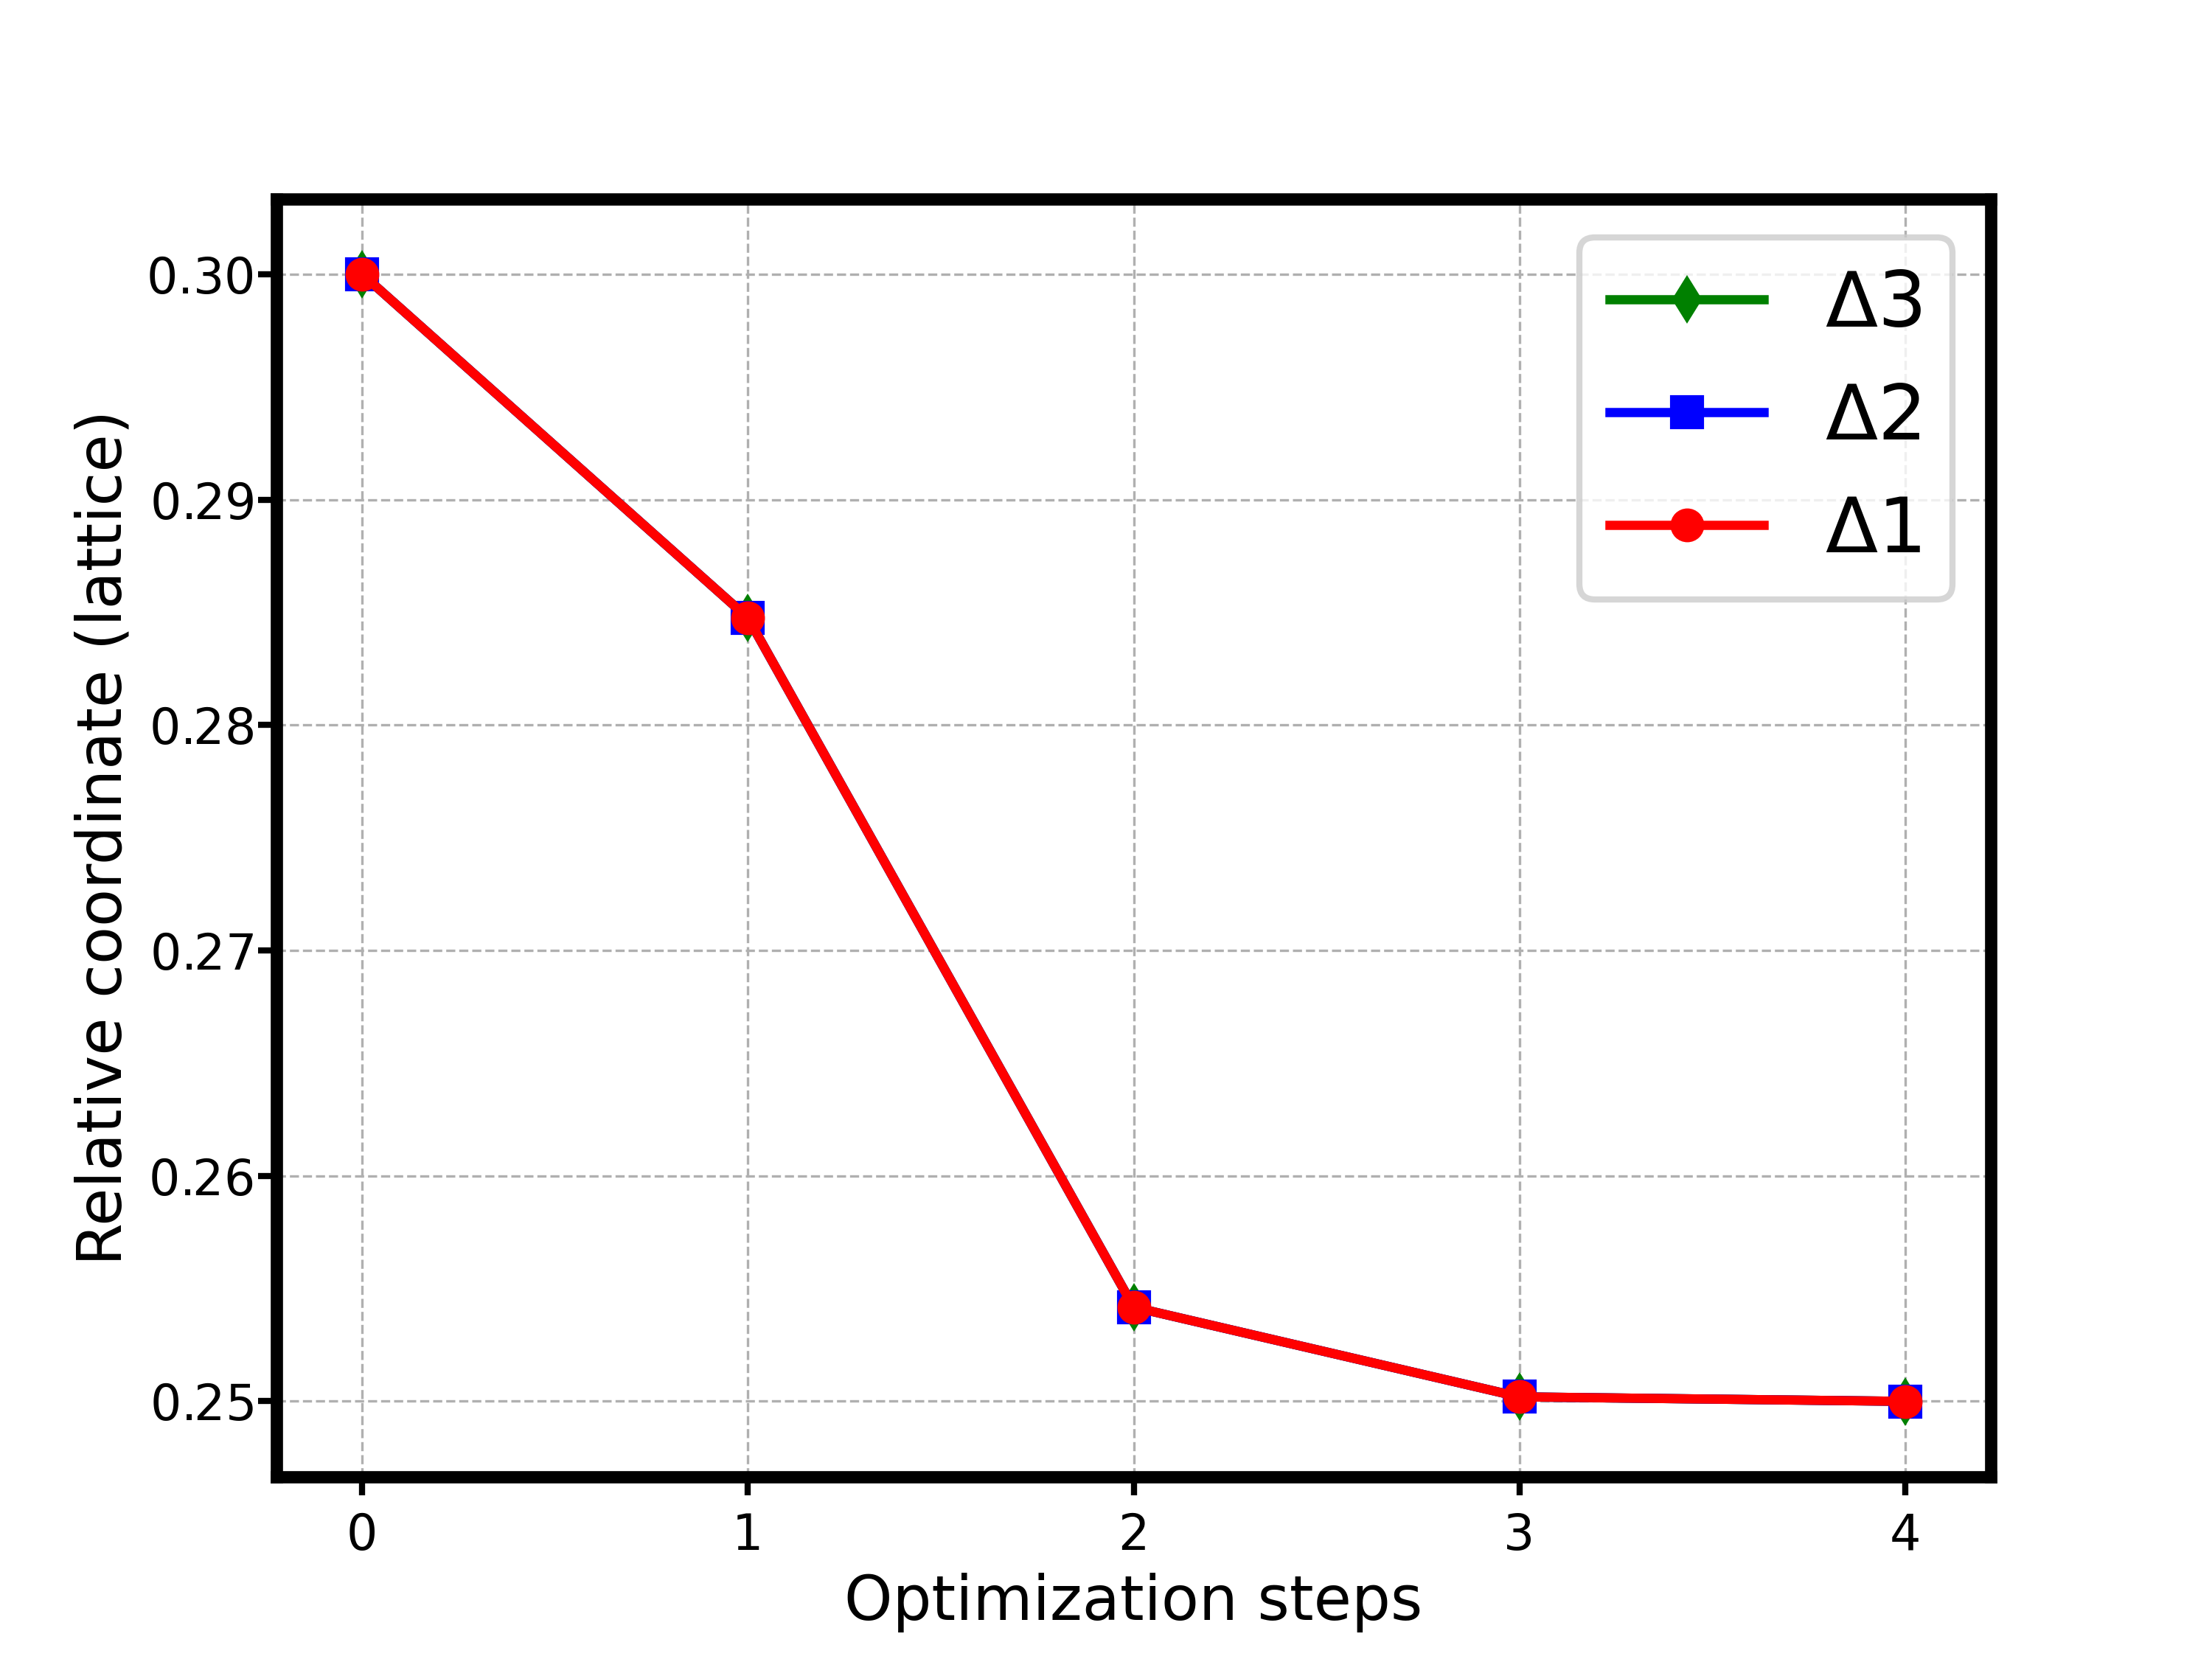
</figure>

Here, <span style="color:mediumblue;font-weight:bold">(Δ1, Δ2, Δ3)</span> represents the 3D vector joining the 2 atoms in the unit cell, expressed in crystal coordinates. Notice that in this example, due of the symmetry of the system and of the initial configuration, the three components <span style="color:mediumblue;font-weight:bold">(Δ1, Δ2, Δ3)</span> are identical, resulting in a single visible curve.

The following optional entries, which can be specified <span style="color:firebrick;font-weight:bold">on the command</span> are also supported by this script.
```bash
python3 -m excitingscripts.plot.relaxdistance DIRECTORYNAME ATOM1 ATOM2 YMIN YMAX
```
Here, the first entry on the command line, (<b>DIRECTORYNAME</b>),represents the label (i.e., the name of the working directory) for which you would like to follow the relaxation of the relative atomic coordinates. The default value is the current directory where the script is executed.

The next entries, <b>ATOM1</b>, <b>ATOM2</b>, <b>YMIN</b>, and <b>YMAX</b>, have the following meaning:

* The entries <b>ATOM1</b> and <b>ATOM2</b> may assume integer values from 1 to the number of atoms in the unit cell. The script will plot the relative position of the atom with index <b>ATOM2</b> with respect to the position of the atom with index <b>ATOM1</b>. <span style="color:firebrick;font-weight:bold">Default values</span> are <span style="color:firebrick;font-weight:bold">1</span> and <span style="color:firebrick;font-weight:bold">2</span> for <b>ATOM1</b> and <b>ATOM2</b>, respectively.
* Assigning numerical values to the entries <b>YMIN</b> and <b>YMAX</b>, you can set the minimum (<span style="color:firebrick;font-weight:bold">YMIN</span>) and the maximum (<span style="color:firebrick;font-weight:bold">YMAX</span>) value on the vertical axis, respectively. As an example, using the command

<b>ii) <code><b>plot.status.py</b></code></b>

Python visualization tool for the root mean square (<b>RMS</b>) deviations of the effective <b>SCF</b> potential as a function of the iteration number during the <b>SCF</b> loop. It is executed as follows.

In [ ]:
%%bash -l
cd run_diamond_relax
python3 -m excitingscripts.plot.status 
cd ..

Here, the entry on the command line, the <b>DIRECTORYNAME</b>, can be specified and represents the name of the directory where an <code><b>exciting</b></code> calculation has been completed or it is still running. The default value is the current directory where the script is executed. The <code><b>plot.status.py</b></code> script is particularly useful in the latter case because one can follow "<i>live</i>" the convergence of the calculation. As an example, using the command

the <b>PNG</b> output of the script should look like the following.

<figure>
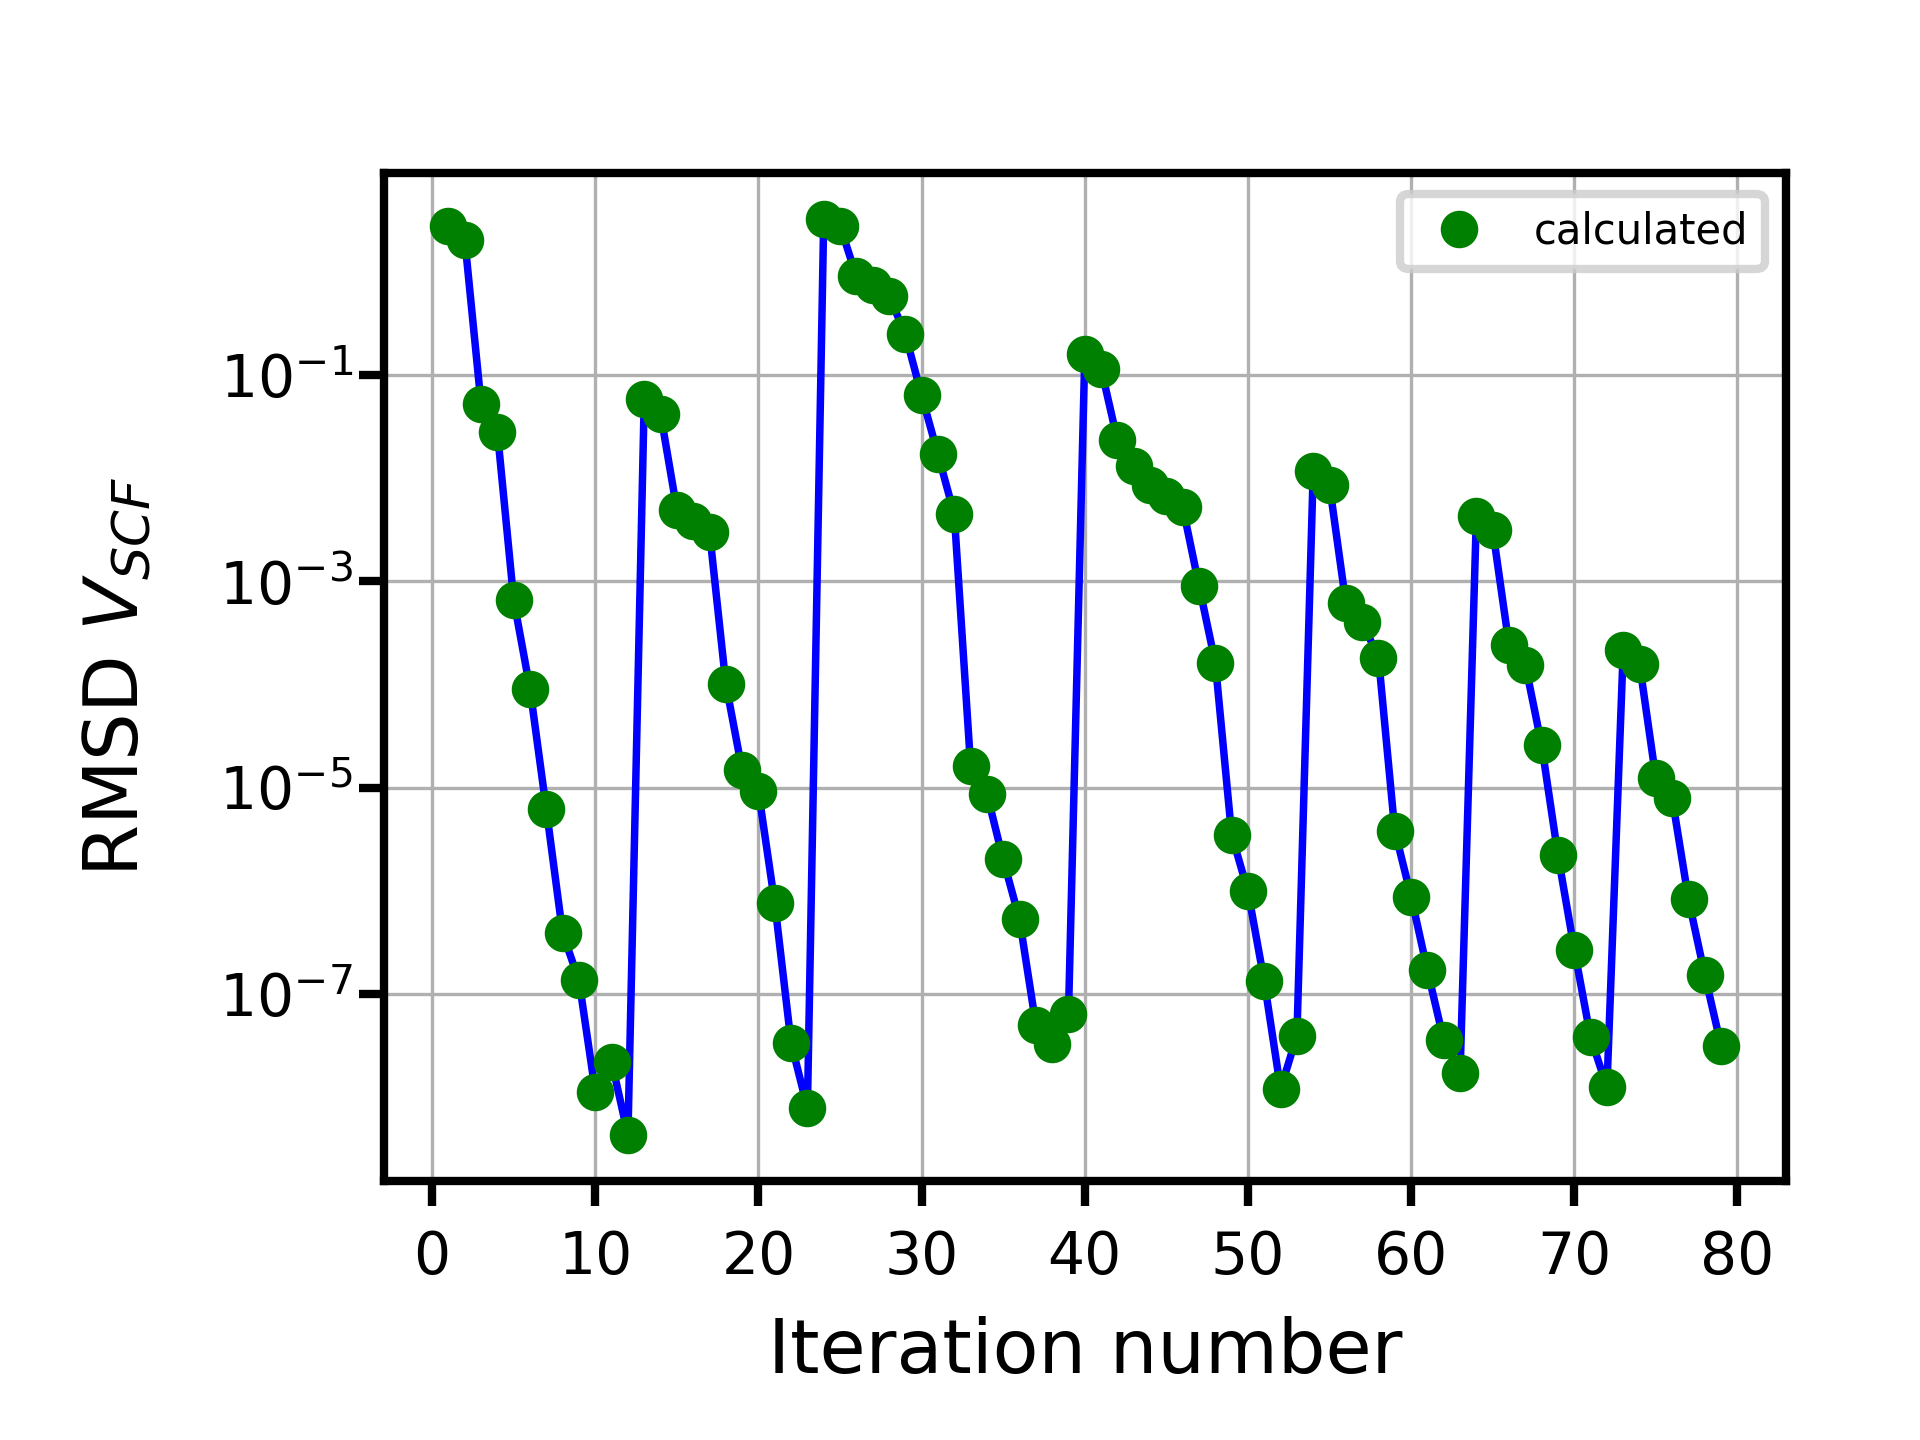
</figure>
    

The different line segments correspond to <b>SCF</b> calculations for different geometries during the relaxation procedure.

<b>iii) <code><b>plot.maxforce.py</b></code></b>

Python visualization tool for the maximum amplitude of the force on the atoms during relaxation. It is executed as follows.

In [ ]:
%%bash -l
python3 -m excitingscripts.plot.maxforce -r run_diamond_relax
cd ..

The input entry definition is the same as for the script <code><b>plot.status.py</b></code>. As an example, using the command

the <b>PNG</b> output of the script should look like the following.

<figure>
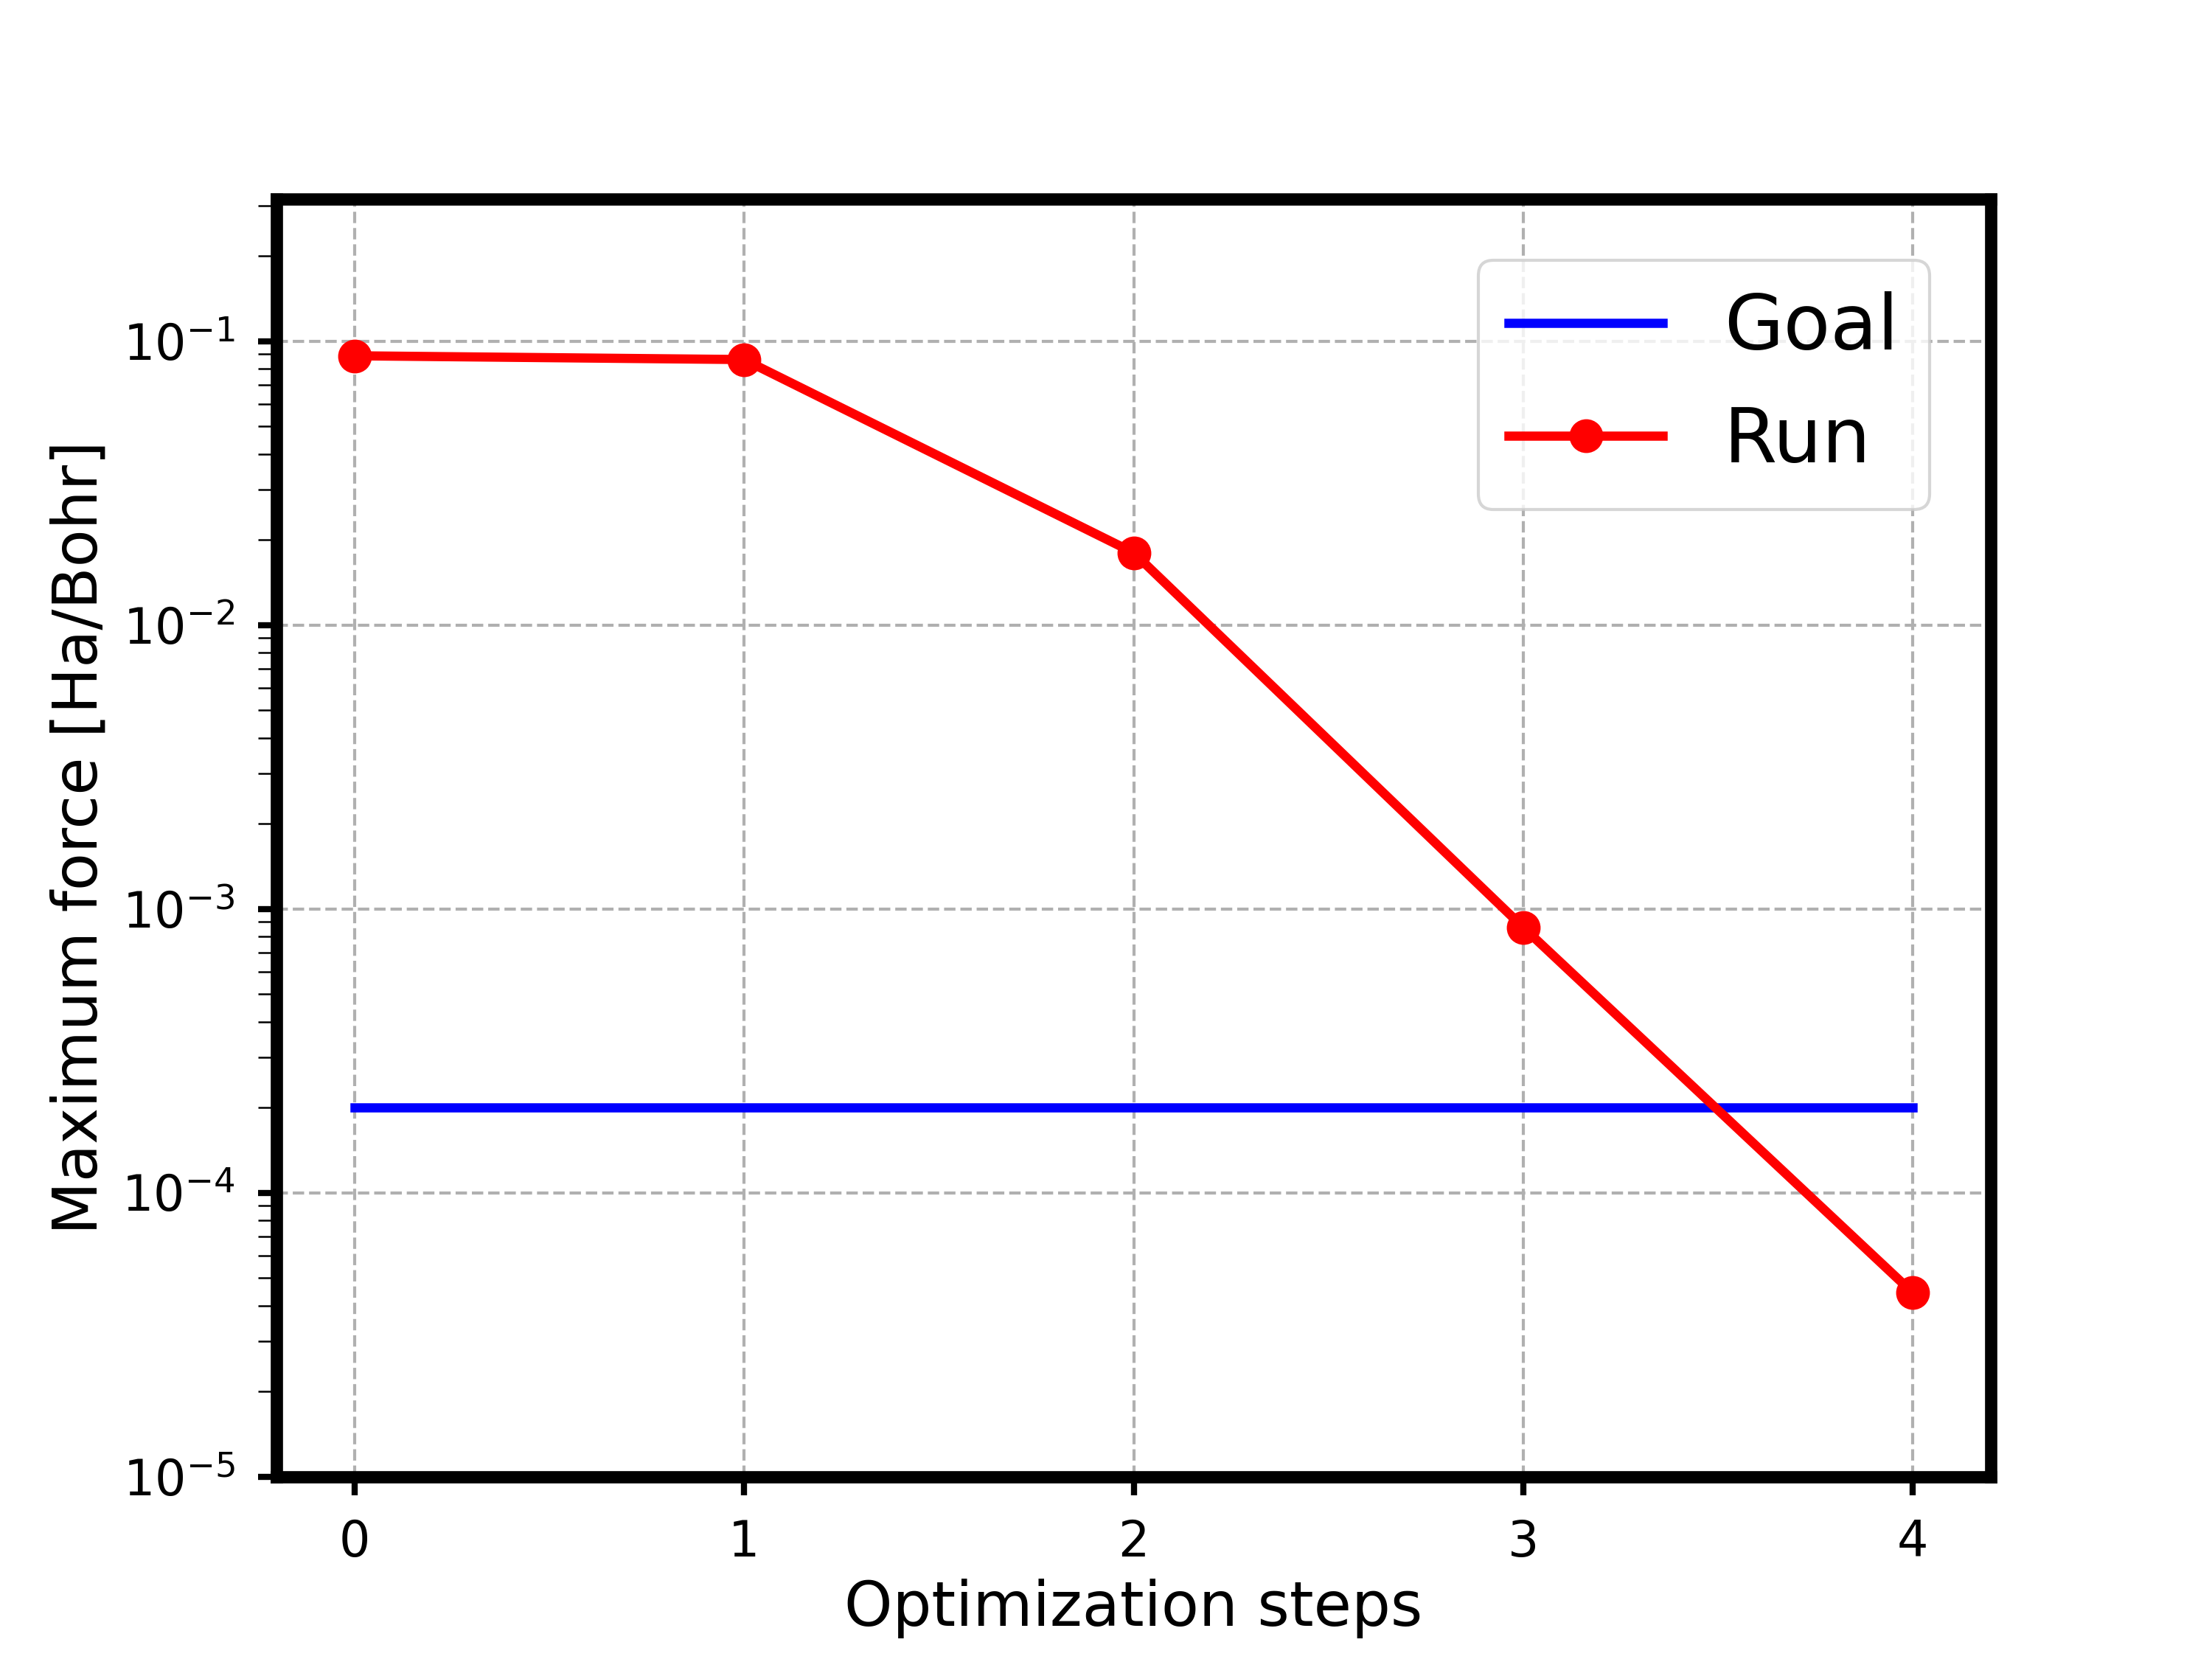
</figure>

    
The <span style="color:red;font-weight:bold">red</span> points show the calculated value at each iteration, whereas the <span style="color:mediumblue;font-weight:bold">blue</span> line indicates the target value (set by the attribute <code><span style="color:mediumblue">epsforce</span></code> inside <code><span style="color:green">relax</span></code>) for the maximum amplitude of the force for stopping the relaxation.

<a id='4'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">4. Diamond: Additional exercises</span>

<b>i) Change the relaxation method</b>

<code><b>exciting</b></code> can perform the optimization of the position of the atoms in the unit cell using three different methods. The application of one of the three available methods can be triggered by setting the attribute <code><span style="color:mediumblue">method</span></code> (see [<span style="color:firebrick;font-weight:bold">Input Reference</span>](https://www.exciting-code.org/home/about/input-reference)) of the element <code><span style="color:green">relax</span></code> to one of the following choices.

Method | Description  
:--- | :--- 
<code><span style="text-align: left;  color:black; font-weight: bold">"bfgs"</span></code> | (<span style="color:red;font-weight:bold">default</span>) Limited memory algorithm for bound constrained optimization, see Byrd, <i>et al.</i> SIAM J. Scientific Computing <b>16</b>, 1190 (1995). This method requires high accuracy for the determination of the total energy in dependence of the maximum allowed for the residual atomic force. For this reason, the default value of the attribute <code><span style="color:mediumblue">epsengy</span></code> (defined in <code><span style="color:green">groundstate</span></code>) is decreased in order to be at least equal to the value of the attribute <code><span style="color:mediumblue">epsforce</span></code> of the <code><span style="color:green">relax</span></code> element multiplied by a factor 0.02. The range of variation of each degree of freedom is set by the attribute <code><span style="color:mediumblue">taubfgs</span></code>. |
<code><span style="text-align: left;  color:black; font-weight: bold">"newton"</span></code> |Simple (Newton-like) method. At each step of a structural optimization run, each atom is displaced proportionally to the force acting on it. The proportionality constant is given by the value of the attribute <code><span style="color:mediumblue">taunewton</span></code>. The optimal choice for this parameter is system dependent and should be adjusted in order to have the most efficient optimization. | 
<code><span style="text-align: left;  color:black; font-weight: bold">"harmonic"</span></code> |Method based on the combination of the <code><span style="color:black; font-weight: bold">"newton"</span></code> method and the harmonic approximation. Contrary to <code><span style="color:black; font-weight: bold">"newton"</span></code>, all cartesian components of the position vector of each atom are treated independently. At the each optimization step each cartesian component of the position vector of each atom is updated using the same algorithm as in <code><span style="color:black; font-weight: bold">"newton"</span></code> ("<i>newton step</i>") unless the "<i>harmonic condition</i>"  is fulfilled. In this case ("<i>harmonic step</i>"), atomic positions are updated according to a linear interpolation of the forces at the last two optimization steps. The <code><span style="color:black; font-weight: bold">"harmonic"</span></code> method is of general validity and it is particularly efficient when the atomic configuration is close to the optimized one and the internal degrees of freedom are weakly coupled. |

Change the input file by explicitly changing the attribute <code><span style="color:mediumblue">method</span></code> and adding <code><span style="color:mediumblue">taunewton</span></code> inside <code><span style="color:green">relax</span></code> and choose for method a value different from the default, e.g.

```xml
...
   <relax
      method="harmonic"
      taunewton="0.2" />
...
```

* <span style="color:green;font-weight:bold">How many optimization runs are needed for reaching the convergence for the different methods?</span>
* <span style="color:green;font-weight:bold">How much <span style="color:black"><b>CPU</b></span> time is required by the different methods?</span>
* <span style="color:green;font-weight:bold">What is the most efficient method for this example for diamond?</span>
* <span style="color:green;font-weight:bold">What does it change if you execute an input file with the following parameters?</span>

```xml
...
   <relax
      method="harmonic"
      taunewton="0.4" />
...
```

<b>ii) Change the initial position</b>

Change the initial position of the second atom in the unit cell according to the following (<span style="color:green;font-weight:bold">non symmetrical choice</span>).

```xml
...
      <species speciesfile="C.xml" rmt="1.20">
         <atom coord="0.00 0.00 0.00" />
         <atom coord="0.30 0.20 0.37" />
      </species>
...
   <relax
      taubfgs="0.3" />
...
```

Perform a new calculation.

* <span style="color:green;font-weight:bold">Why do you expect a longer execution time in this case?</span>

<b>iii) Change the lattice parameter</b>

Set the cubic lattice constant to a smaller value, as in the following example.

```xml
...
      <crystal scale="5.0">
...
```

Due to the smaller volume (and distances), set the muffin-tin radius of the carbon atoms to a smaller value.

```xml
...
      <species speciesfile="C.xml" rmt="1.05">
...
```

Set the initial coordinates of the second atom according to

```xml
...
         <atom coord="0.00 0.00 0.00" />
         <atom coord="0.45 0.45 0.45" />
...
```

Include the new parameter <code><span style="color:mediumblue">gmaxvr</span></code> in the <code><span style="color:green">groundstate</span></code> element (this addition is needed due to the strongly reduced value of the lattice constants which is used in this calculations, see [<span style="color:firebrick;font-weight:bold">Input Reference</span>](https://www.exciting-code.org/home/about/input-reference)).

```xml
...
   <groundstate 
      ngridk="6 6 6"
      gmaxvr="15"
      swidth="0.0001">
      ...
   </groundstate>
...
```
          
Perform a new calculation.

* <span style="color:green;font-weight:bold">What are the equilibrium relative atomic coordinates in this case?</span>
* <span style="color:green;font-weight:bold">What happens if the initial coordinates of the second atom are set to (0.26, 0.26, 0.26)? (<span style="color:black;font-weight:normal"><b>Hint</b>: set</span> rmt = <span style="color:black">"0.95"</span>)</span> 
* <span style="color:green;font-weight:bold">What is the physical meaning of this result?</span>

<hr style="border:2px solid #DDD"> </hr>